In [1]:
import os
import numpy as np
import sys
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [3]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
latent_array = joblib.load(os.path.join(root_dir, 'latent_array_plus6_ctrl_y.pkl'))
patch_label_df = pd.read_csv(os.path.join(root_dir, 'patch_label_df.csv'))


In [4]:
latent_array_np_lat8 = latent_array[:,:8]
latents_lat8_2d = UMAP_train(latent_array_np_lat8, root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8only_UMAP2_20251222')

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [5]:
patch_label_df['UMAP_d0'] = latents_lat8_2d[:,0]
patch_label_df['UMAP_d1'] = latents_lat8_2d[:,1]


In [6]:
patch_label_df['lat_d0'] = latent_array_np_lat8[:,0]
patch_label_df['lat_d1'] = latent_array_np_lat8[:,1]
patch_label_df['lat_d2'] = latent_array_np_lat8[:,2]
patch_label_df['lat_d3'] = latent_array_np_lat8[:,3]
patch_label_df['lat_d4'] = latent_array_np_lat8[:,4]
patch_label_df['lat_d5'] = latent_array_np_lat8[:,5]
patch_label_df['lat_d6'] = latent_array_np_lat8[:,6]
patch_label_df['lat_d7'] = latent_array_np_lat8[:,7]

In [7]:
patch_label_df

,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,vinculin_intensity,pax_intensity,...,dist_cell_edge,front_flag,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
0,0,ctrl,f0000x0080y0816ps32.tif,0,6.533898,2.949632,0,0,3470.368164,10741.897461,...,0.0,0.0,4.793272,20.604002,5.372108,-7.815341,1.760113,32.959721,-21.882824,2.258103
1,1,ctrl,f0000x0112y0784ps32.tif,0,0.613508,-1.430238,0,0,2753.338867,8699.333984,...,0.0,0.0,0.826394,-3.398712,-2.768886,5.473682,-1.714877,1.444764,-5.044192,-2.793007
2,2,ctrl,f0000x0144y0784ps32.tif,0,4.134789,1.867131,0,0,4177.766602,12690.236328,...,8.0,0.0,10.628540,3.866692,-0.625196,2.456605,0.941578,6.303121,-6.728461,-7.896038
3,3,ctrl,f0000x0176y0784ps32.tif,0,6.328398,2.741769,0,0,3782.319336,9358.561523,...,4.0,0.0,13.097126,9.377098,7.463983,-0.638954,3.322603,22.364613,-18.249426,0.339599
4,4,ctrl,f0000x0240y0752ps32.tif,0,5.109221,1.633341,0,0,3487.683594,8591.057617,...,6.0,0.0,15.051421,4.962876,1.968619,4.266151,3.475077,12.175271,-11.814137,-9.985755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23651,23651,y,f0040x0912y0624ps32.tif,1,6.696744,0.453905,0,0,4753.446289,6024.557617,...,24.0,255.0,-4.928203,4.098186,-5.373686,4.427641,-0.110387,9.007499,-16.987860,-2.702754
23652,23652,y,f0040x0912y0656ps32.tif,1,5.160360,1.301750,0,0,8459.265625,8512.615234,...,25.0,255.0,9.884430,6.437505,1.430342,7.115860,2.850735,12.949064,-10.358782,-3.006688
23653,23653,y,f0040x0912y0688ps32.tif,1,3.375209,-0.521952,0,0,7675.988281,8302.816406,...,28.0,255.0,1.726854,-1.704976,-4.656003,1.686419,1.671660,7.410644,-7.135116,-0.333692
23654,23654,y,f0040x0912y0720ps32.tif,1,5.753994,-0.231215,0,0,5432.383789,5537.922852,...,16.0,255.0,0.885759,-2.416347,-6.106094,3.669299,-1.798731,8.590202,-13.161478,-6.561848


In [8]:
patch_label_df["group"] = patch_label_df["ctrl_y_str"].map(
    {"ctrl": "control", "y": "ycomp"}
)


patch_label_df["unique_ID"]  = patch_label_df["group"] +'-'+patch_label_df["crop_img_filename"] 


In [9]:
patch_label_df.to_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))

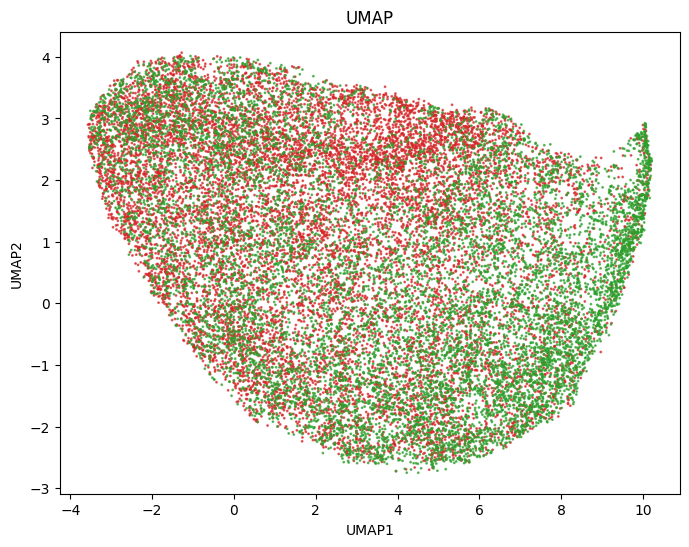

In [10]:
fig = umap_2Dplot(latents_lat8_2d, 0,1,1-patch_label_df['group_labels']+1)

In [11]:
def ctrl_Y_ID_adding(label_df):
    label_df["group"] = (
    label_df["czi_filename"]
    .str.lower()
    .str.extract(r"(control|ycomp)", expand=False)
    )
  
    label_df["group_ID"] = label_df["group"].map(
    {"control": 0, "ycomp": 1}
    )


    label_df["unique_ID"]  = label_df["group"] +'-'+label_df["crop_img_filename"] 

    return label_df
        

In [12]:

df_C_day1218 = ctrl_Y_ID_adding(pd.read_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-18-15-32-df671bd2.csv'))
df_C_day1219 = ctrl_Y_ID_adding(pd.read_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-19-15-41-effff775.csv'))

df_Y_day1222 = ctrl_Y_ID_adding(pd.read_csv('/mnt/d/lding/FA/analysis_results/labelling/project-15-at-2025-12-22-18-44-b7e23381.csv'))



In [13]:
df_merged_day121819 = pd.merge(df_C_day1218,df_C_day1219,on='crop_img_filename',how='inner')
df_merged_day121819.to_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-18-19-merged-inner.csv')

In [14]:
df_merged_day121819_outer = pd.merge(df_C_day1218,df_C_day1219,on='crop_img_filename',how='outer')
df_merged_day121819_outer.to_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-18-19-merged_outer.csv')

In [15]:

df_C_merged_day121819_on1219 = (
    pd.concat([df_C_day1218, df_C_day1219], ignore_index=True)
      .drop_duplicates(subset="crop_img_filename", keep="last")
)

df_C_merged_day121819_on1219.to_csv('/mnt/d/lding/FA/analysis_results/labelling/project-13-at-2025-12-18-19-merged_on1219.csv')

In [16]:
df_CY_merged_day12181922 = pd.concat([df_C_merged_day121819_on1219, df_Y_day1222], ignore_index=True)

In [17]:
lat8_df = patch_label_df[['unique_ID','lat_d0','lat_d1','lat_d2','lat_d3','lat_d4','lat_d5','lat_d6','lat_d7','UMAP_d0','UMAP_d1','dist_cell_edge','front_flag']]

In [18]:
lat8_margaret_label_121922 = lat8_df.merge(
    df_CY_merged_day12181922[['unique_ID','Position','classification','group_ID','group']],
    on="unique_ID",
    how="right"
)

In [ ]:
patch_label_df.to_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))
lat8_margaret_label_121922.to_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))

In [19]:
lat8_margaret_label_121922

,unique_ID,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7,UMAP_d0,UMAP_d1,dist_cell_edge,front_flag,Position,classification,group_ID,group
0,control-f0001x0592y0560ps32.tif,-0.983314,-2.404803,-3.736503,6.555636,0.042419,6.967061,-8.542937,-4.755290,4.961792,-1.905312,51.0,0.0,Cell Body,No adhesion,0,control
1,control-f0001x0688y0848ps32.tif,-4.863095,-3.715334,-3.399110,5.652102,0.032057,8.218933,-11.530948,-4.186346,6.798612,-2.101816,105.0,0.0,Lamella,No adhesion,0,control
2,control-f0001x0592y0592ps32.tif,-1.803649,-2.869361,-1.006975,3.253512,0.877270,5.041645,-6.751046,-2.243623,2.566195,-2.282539,83.0,0.0,Cell Body,No adhesion,0,control
3,control-f0001x0368y0528ps32.tif,-3.296754,-2.140397,1.562945,5.854156,4.291277,12.685116,-13.712293,-2.580447,7.103175,-0.058455,5.0,0.0,Cell Periphery/other,No adhesion,0,control
4,control-f0001x0592y0528ps32.tif,2.648586,3.077546,4.824249,5.175311,1.487612,9.489152,-10.581527,-0.956125,4.539909,0.757580,19.0,0.0,Cell Periphery/other,No adhesion,0,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,ycomp-f0039x0720y0752ps32.tif,0.990941,-2.684233,1.284537,0.897436,4.290197,10.083295,-12.114593,-7.051551,5.978190,-0.200518,8.0,255.0,Cell Protruding Edge,focal complex,1,ycomp
385,ycomp-f0039x0240y0656ps32.tif,-0.143192,-2.601841,-2.787721,4.788752,3.742576,10.644148,-12.272271,-1.724936,6.268112,-0.823599,12.0,255.0,Cell Periphery/other,Nascent Adhesion,1,ycomp
386,ycomp-f0039x0688y0592ps32.tif,-1.135026,-1.093894,-4.306705,5.795660,-0.412325,9.808274,-6.398516,0.391343,3.894204,-0.520346,171.0,0.0,Lamella,No adhesion,1,ycomp
387,ycomp-f0039x0304y0592ps32.tif,-1.162817,0.986429,1.793646,6.831646,-2.493236,7.423744,-10.250132,3.400178,4.503439,0.089625,120.0,0.0,Lamella,No adhesion,1,ycomp


In [20]:
tab10_colors = [
    "#1f77b4",  # 0 - blue
    "#ff7f0e",  # 1 - orange
    "#2ca02c",  # 2 - green
    "#d62728",  # 3 - red
    "#9467bd",  # 4 - purple
    "#8c564b",  # 5 - brown
    "#e377c2",  # 6 - pink
    "#7f7f7f",  # 7 - gray
    "#bcbd22",  # 8 - olive
    "#17becf",  # 9 - cyan
]

In [43]:
lat8_margaret_label_121922['classification'].unique()

array(['No adhesion', 'focal adhesion', 'Nascent Adhesion',
       'fibrillar adhesion', 'focal complex', 'Uncertain'], dtype=object)

In [70]:
classification_label_order

['Nascent Adhesion',
 'focal complex',
 'focal adhesion',
 'fibrillar adhesion',
 'No adhesion',
 'Uncertain']

In [71]:
classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]


classification_label_to_color = {
    cls: tab10_colors[i]
    for i, cls in enumerate(classification_label_order)
}

fa_label_to_id = {
    cls: i
    for i, cls in enumerate(classification_label_order)
}

lat8_margaret_label_121922["FA_type_id"] = (
    lat8_margaret_label_121922["classification"]
        .map(fa_label_to_id)
)

In [72]:
position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]

position_label_to_color = {
    cls: tab10_colors[i]
    for i, cls in enumerate(position_label_order)
}

position_label_to_id = {
    cls: i
    for i, cls in enumerate(position_label_order)
}

lat8_margaret_label_121922["position_id"] = (
    lat8_margaret_label_121922["Position"]
        .map(position_label_to_id)
)

In [73]:
# classification_label_to_color = {
#     "Nascent Adhesion": 1,
#     "focal complex": 2,
#     "focal adhesion": 3,
#     "fibrillar adhesion": 4,
#     "No adhesion": 5,
#     "Uncertain":6
# }

# lat8_margaret_label_121922["FA_type_id"] = lat8_margaret_label_121922["classification"].map(classification_label_to_color)


# position_label_to_color = {
#     "Cell Protruding Edge": 1,
#     "Cell Periphery/other": 2,
#     "Lamella": 3,
#     "Cell Body": 4,
#     "No Category/uncertain": 5
# }

# lat8_margaret_label_121922["position_id"] = lat8_margaret_label_121922["Position"].map(position_label_to_color)


In [74]:
lat8_margaret_label_121922.columns

Index(['unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5',
       'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1', 'dist_cell_edge',
       'front_flag', 'Position', 'classification', 'group_ID', 'group',
       'FA_type_id', 'position_id'],
      dtype='object')

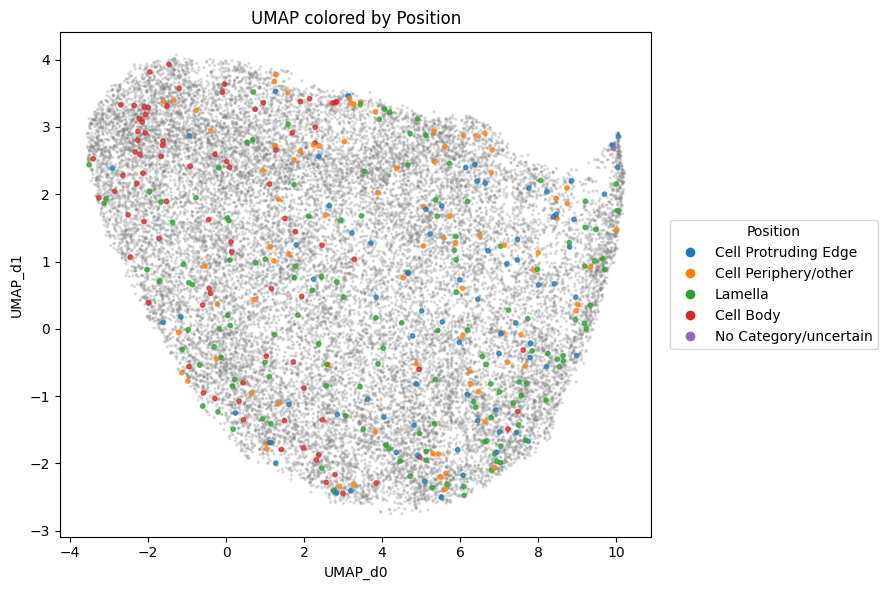

In [75]:
plt.figure(figsize=(9, 6))

plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    lat8_margaret_label_121922["UMAP_d0"],
    lat8_margaret_label_121922["UMAP_d1"],
    c=lat8_margaret_label_121922["Position"].map(position_label_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by Position")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=position_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in position_label_order
]
plt.legend(
    handles=handles,
    title="Position",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()


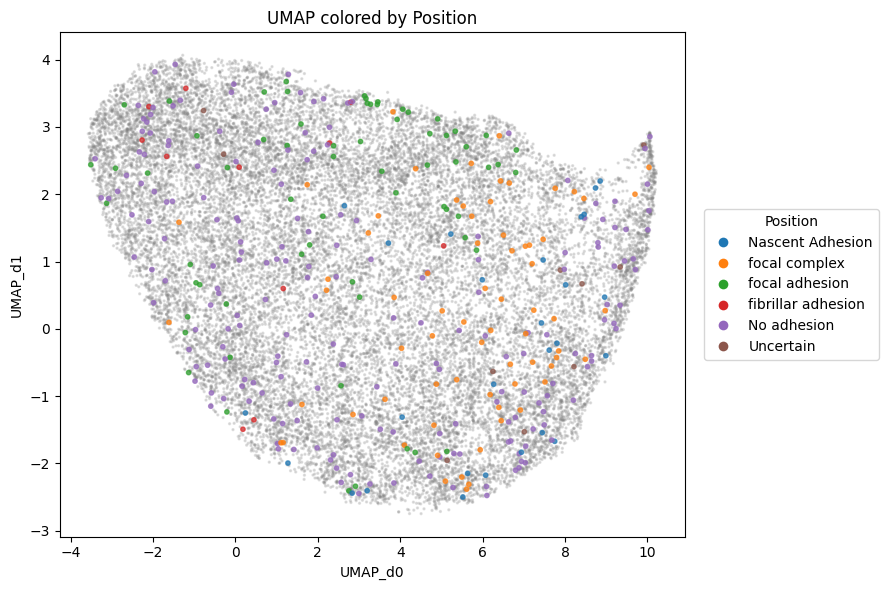

In [76]:

plt.figure(figsize=(9, 6))

plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  

plt.scatter(
    lat8_margaret_label_121922["UMAP_d0"],
    lat8_margaret_label_121922["UMAP_d1"],
    c=lat8_margaret_label_121922["classification"].map(classification_label_to_color),
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP_d0")
plt.ylabel("UMAP_d1")
plt.title("UMAP colored by Position")

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=classification_label_to_color[label],
           markeredgecolor="none",
           markersize=7, label=label)
    for label in classification_label_order
]
plt.legend(
    handles=handles,
    title="Position",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
plt.tight_layout()
plt.show()


In [78]:
df_clean = lat8_margaret_label_121922[lat8_margaret_label_121922["classification"] != "Uncertain"].copy()


In [79]:
df_clean.columns

Index(['unique_ID', 'lat_d0', 'lat_d1', 'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5',
       'lat_d6', 'lat_d7', 'UMAP_d0', 'UMAP_d1', 'dist_cell_edge',
       'front_flag', 'Position', 'classification', 'group_ID', 'group',
       'FA_type_id', 'position_id'],
      dtype='object')

In [80]:
lat_cols = [f"lat_d{i}" for i in range(8)]

X = df_clean[lat_cols].values
y_FA_class = df_clean["classification"].values
y_position = df_clean["Position"].values

y_FA_class_enc = df_clean["FA_type_id"].values
y_position_enc = df_clean["position_id"].values


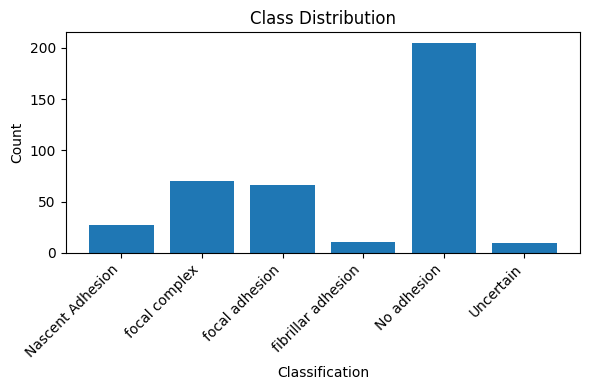

In [81]:
import matplotlib.pyplot as plt
import numpy as np

class_names = classification_label_order
n_classes = len(class_names)

y_enc = lat8_margaret_label_121922["FA_type_id"].dropna().astype(int).values

plt.figure(figsize=(6, 4))

plt.hist(
    y_enc,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Classification")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.tight_layout()
plt.show()


In [103]:

ct = pd.crosstab(
    lat8_margaret_label_121922["Position"],
    lat8_margaret_label_121922["classification"]
)


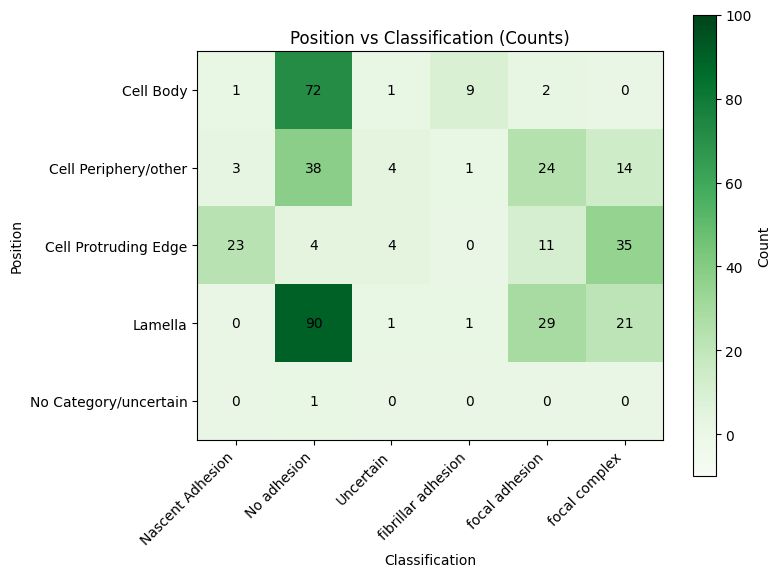

In [169]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(ct.values,cmap='Greens', vmin=-10,vmax=100)

ax.set_xticks(np.arange(ct.shape[1]))
ax.set_yticks(np.arange(ct.shape[0]))

ax.set_xticklabels(ct.columns, rotation=45, ha="right")
ax.set_yticklabels(ct.index)

ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position vs Classification (Counts)")

# annotate cells
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j],
                ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()


In [83]:
indices = np.arange(len(X))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y_FA_class_enc,   # primary task
    random_state=42
)

X_train = X[train_idx]
X_val   = X[val_idx]

y_FA_class_train = y_FA_class_enc[train_idx]
y_FA_class_val   = y_FA_class_enc[val_idx]

y_position_train = y_position_enc[train_idx]
y_position_val   = y_position_enc[val_idx]


In [84]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])


In [85]:
pipe.fit(X_train, y_FA_class_train)


/home/ldin/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [89]:
classification_label_order

['Nascent Adhesion',
 'focal complex',
 'focal adhesion',
 'fibrillar adhesion',
 'No adhesion',
 'Uncertain']

In [88]:
y_FA_class_pred

array([3, 3, 0, 1, 0, 4, 3, 4, 3, 0, 1, 3, 4, 4, 4, 2, 2, 0, 1, 2, 0, 4,
       2, 4, 4, 3, 0, 4, 0, 4, 3, 4, 3, 4, 2, 4, 0, 0, 3, 2, 2, 0, 3, 3,
       1, 2, 4, 2, 0, 4, 2, 2, 1, 3, 0, 4, 0, 3, 3, 0, 4, 2, 1, 0, 3, 3,
       1, 3, 0, 0, 3, 2, 1, 3, 2, 0])

In [90]:
y_FA_class_pred = pipe.predict(X_val)

print("Validation classification report:")
print(classification_report(
    y_FA_class_val,
    y_FA_class_pred,
    target_names=classification_label_order[:-1]
))


Validation classification report:
                    precision    recall  f1-score   support

  Nascent Adhesion       0.17      0.50      0.25         6
     focal complex       0.50      0.29      0.36        14
    focal adhesion       0.36      0.38      0.37        13
fibrillar adhesion       0.05      0.50      0.10         2
       No adhesion       0.71      0.29      0.41        41

          accuracy                           0.33        76
         macro avg       0.36      0.39      0.30        76
      weighted avg       0.55      0.33      0.38        76



In [91]:
cm = confusion_matrix(y_FA_class_val, y_FA_class_pred)

cm_df = pd.DataFrame(
    cm,
    index=classification_label_order[:-1],
    columns=classification_label_order[:-1]
)

cm_df


,Nascent Adhesion,focal complex,focal adhesion,fibrillar adhesion,No adhesion
Nascent Adhesion,3,2,0,1,0
focal complex,4,4,2,2,2
focal adhesion,1,1,5,3,3
fibrillar adhesion,0,0,1,1,0
No adhesion,10,1,6,12,12


In [92]:
coef = pd.DataFrame(
    pipe.named_steps["clf"].coef_,
    columns=lat_cols,
    index=classification_label_order[:-1]
)

coef


,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
Nascent Adhesion,-0.186912,-0.567023,-0.142401,0.720936,0.082888,-0.218361,-0.476107,-0.564208
focal complex,-0.024718,0.103051,-0.245713,0.755272,-0.119872,0.754378,0.210216,-0.200639
focal adhesion,-0.178513,0.933925,-0.013559,-0.688798,0.043810,0.194090,-0.198318,0.325999
fibrillar adhesion,0.668782,-0.674895,0.501405,-1.028613,-0.167923,-0.438100,0.914276,0.077962
No adhesion,-0.278639,0.204941,-0.099732,0.241202,0.161097,-0.292008,-0.450068,0.360887


In [93]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_FA_class_val, y_FA_class_pred)
class_names = classification_label_order[:-1]


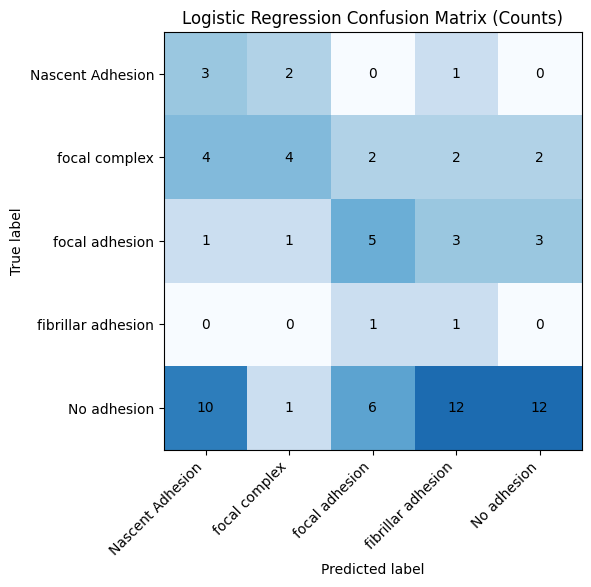

In [94]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm),  cmap="Blues",vmax=4.5)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Logistic Regression Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


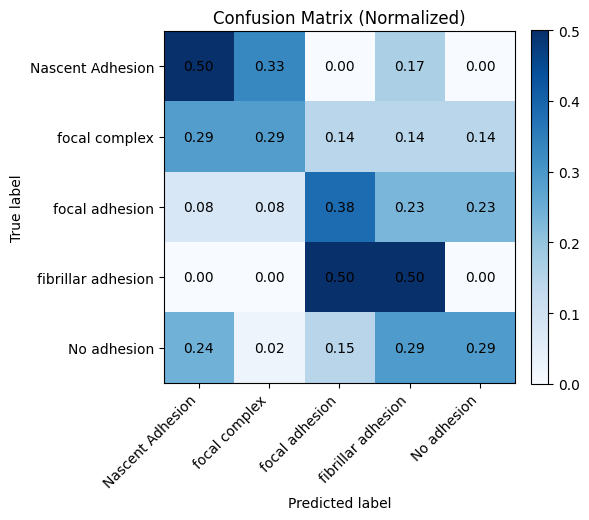

In [95]:
from matplotlib.colors import PowerNorm

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 6))


im = ax.imshow(
    cm_norm,
    cmap="Blues"
)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Normalized)")

# annotate cells
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [99]:
np.sqrt(cm)

array([[1.73205081, 1.41421356, 0.        , 1.        , 0.        ],
       [2.        , 2.        , 1.41421356, 1.41421356, 1.41421356],
       [1.        , 1.        , 2.23606798, 1.73205081, 1.73205081],
       [0.        , 0.        , 1.        , 1.        , 0.        ],
       [3.16227766, 1.        , 2.44948974, 3.46410162, 3.46410162]])

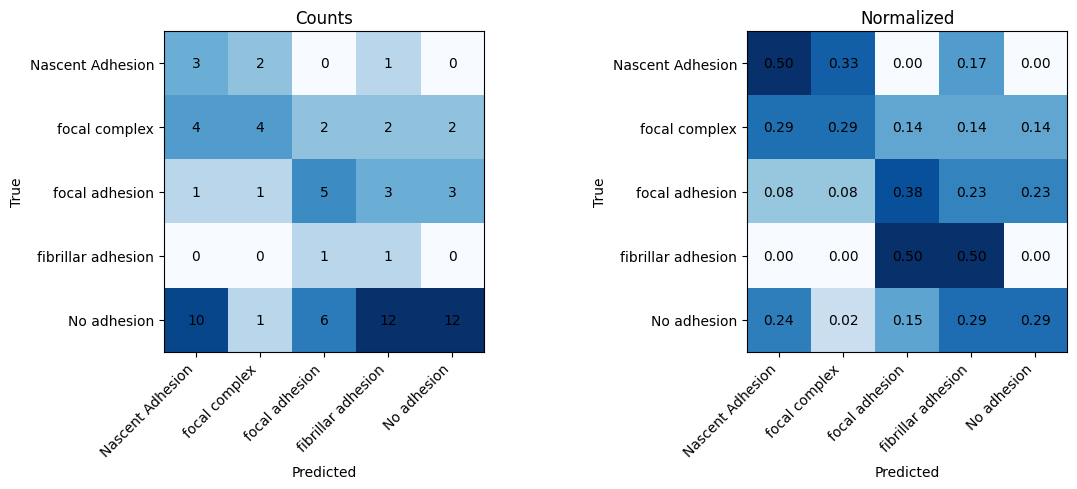

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(
    axes,
    [cm, cm_norm],
    ["Counts", "Normalized"]
):
    im = ax.imshow(np.sqrt(mat),   cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            txt = mat[i, j] if title == "Counts" else f"{mat[i, j]:.2f}"
            ax.text(j, i, txt, ha="center", va="center")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


In [103]:
y_FA_class_train_pred = pipe.predict(X_train)
print("Train accuracy:", (y_FA_class_train_pred == y_FA_class_train).mean())


Train accuracy: 0.36303630363036304


# Logistic regression cannot separate samples
Try other higher level ones

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_FA_class_train)

y_FA_class_pred = rf.predict(X_val)
print(classification_report(y_FA_class_val, y_FA_class_pred, target_names=classification_label_order[:-1]))


                    precision    recall  f1-score   support

  Nascent Adhesion       0.00      0.00      0.00         6
     focal complex       0.37      0.50      0.42        14
    focal adhesion       0.50      0.46      0.48        13
fibrillar adhesion       0.00      0.00      0.00         2
       No adhesion       0.68      0.73      0.71        41

          accuracy                           0.57        76
         macro avg       0.31      0.34      0.32        76
      weighted avg       0.52      0.57      0.54        76



/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [105]:
cm = confusion_matrix(y_FA_class_val, y_FA_class_pred)
class_names = classification_label_order[:-1]


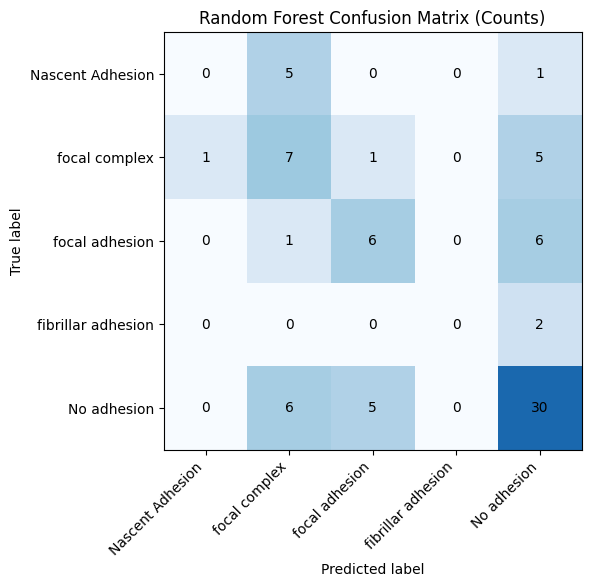

In [106]:
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm),    cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Random Forest Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [107]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_FA_class_train)

y_FA_class_pred = gb.predict(X_val)
print(classification_report(y_FA_class_val, y_FA_class_pred, target_names=classification_label_order[:-1]))


                    precision    recall  f1-score   support

  Nascent Adhesion       0.00      0.00      0.00         6
     focal complex       0.27      0.29      0.28        14
    focal adhesion       0.46      0.46      0.46        13
fibrillar adhesion       0.00      0.00      0.00         2
       No adhesion       0.69      0.76      0.72        41

          accuracy                           0.54        76
         macro avg       0.28      0.30      0.29        76
      weighted avg       0.50      0.54      0.52        76



/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


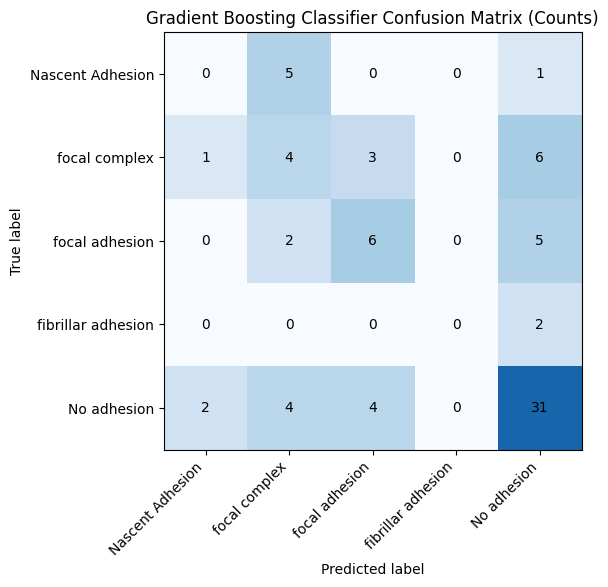

In [108]:
cm = confusion_matrix(y_FA_class_val, y_FA_class_pred)
class_names = classification_label_order[:-1]
fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(np.sqrt(cm), cmap="Blues",vmax=7)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Gradient Boosting Classifier Confusion Matrix (Counts)")

# annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


In [109]:
lat_cols = [f"lat_d{i}" for i in range(8)]

X_all = patch_label_df[lat_cols].values
umap_all_d0 = patch_label_df['UMAP_d0']
umap_all_d1 = patch_label_df['UMAP_d1']
front_flag_all = patch_label_df['front_flag']

y_FA_class_all_pred = gb.predict(X_all)

In [110]:
front_flag_all = patch_label_df['front_flag']

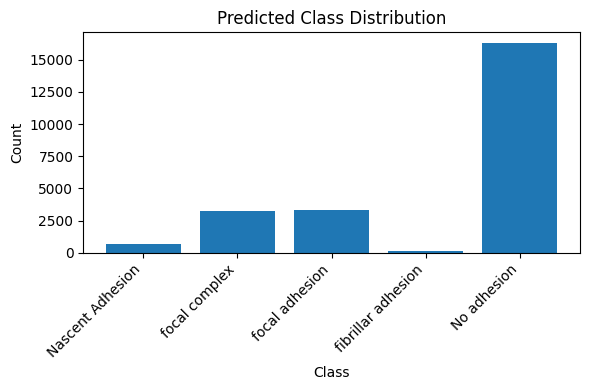

In [111]:
# plt.hist(y_all_pred)



import matplotlib.pyplot as plt
import numpy as np

class_names = classification_label_order[:-1]
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    y_FA_class_all_pred,
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")

plt.tight_layout()
plt.show()


(array([  678.,     0.,  3213.,     0.,     0.,  3295.,     0.,     0.,
          151.,     0., 16319.]),
 array([0.        , 0.36363636, 0.72727273, 1.09090909, 1.45454545,
        1.81818182, 2.18181818, 2.54545455, 2.90909091, 3.27272727,
        3.63636364, 4.        ]),
 <BarContainer object of 11 artists>)

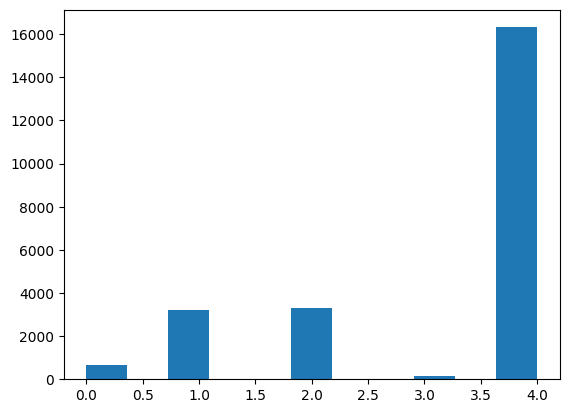

In [113]:
plt.hist(y_FA_class_all_pred,11)

In [114]:
classification_label_to_color

{'Nascent Adhesion': '#1f77b4',
 'focal complex': '#ff7f0e',
 'focal adhesion': '#2ca02c',
 'fibrillar adhesion': '#d62728',
 'No adhesion': '#9467bd',
 'Uncertain': '#8c564b'}

In [115]:
# id -> color (via label)
fa_id_to_color = {
    i: classification_label_to_color[label]
    for i, label in enumerate(classification_label_order)
}

In [117]:
fa_id_to_color

{0: '#1f77b4',
 1: '#ff7f0e',
 2: '#2ca02c',
 3: '#d62728',
 4: '#9467bd',
 5: '#8c564b'}

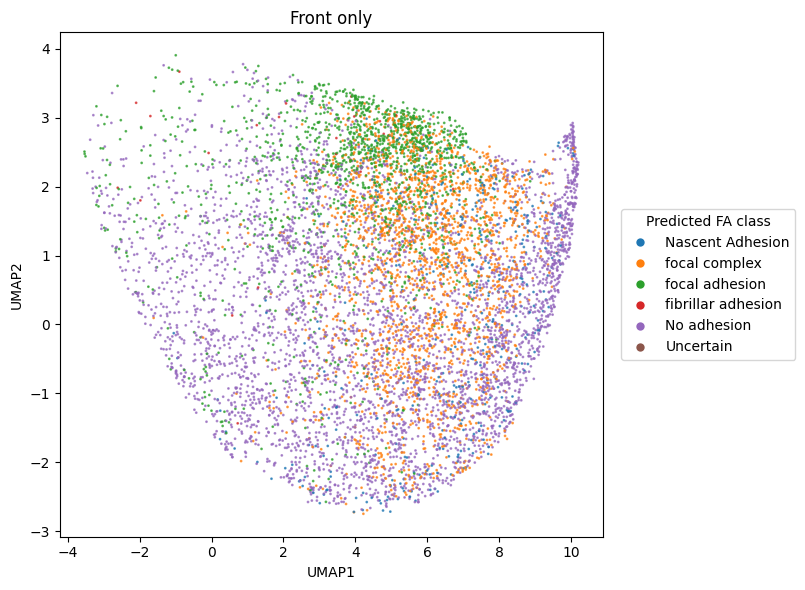

In [ ]:

mask = front_flag_all > 0

pred_ids = y_FA_class_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]

plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Front only")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=classification_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in classification_label_order
]

plt.legend(
    handles=handles,
    title="Predicted FA class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



In [ ]:
mask = y_all_pred_updated_mapping!=5

pred_ids = y_FA_class_all_pred[mask].astype(int)

pred_colors = [fa_id_to_color[i] for i in pred_ids]
plt.figure(figsize=(10, 6))

plt.scatter(
    umap_all_d0[mask],
    umap_all_d1[mask],
    c=pred_colors,
    alpha=0.7,
    s=1
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Front only")

from matplotlib.lines import Line2D

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=classification_label_to_color[label],
        markeredgecolor="none",
        markersize=6,
        label=label
    )
    for label in classification_label_order
]

plt.legend(
    handles=handles,
    title="Predicted FA class(except No Adhesion)",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()



NameError: name 'y_all_pred_updated_mapping' is not defined

Text(0.5, 1.0, 'UMAP')

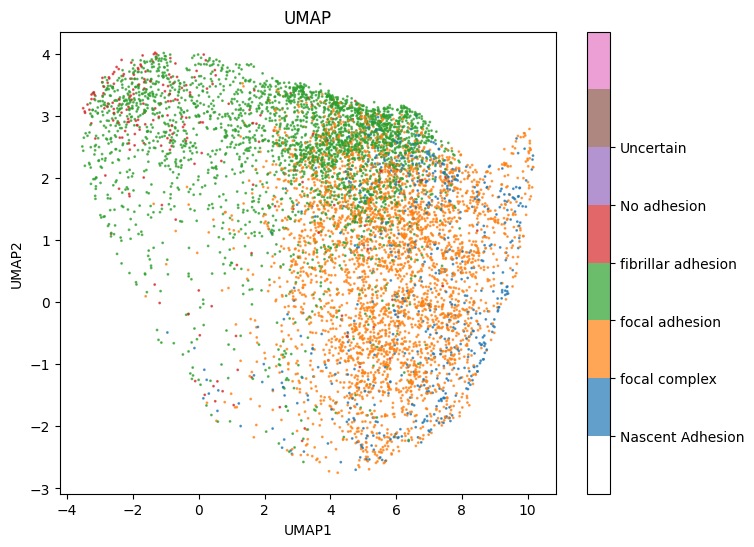

In [ ]:
import matplotlib.pyplot as plt
# fig = umap_2Dplot(latents_plus3_2d, 0,1,5-patch_label_df['group_labels']*0+1)
fig = plt.figure(figsize=(8, 6))
plt.scatter(umap_all_d0[y_all_pred_updated_mapping!=5], umap_all_d1[y_all_pred_updated_mapping!=5], c=y_all_pred_updated_mapping[y_all_pred_updated_mapping!=5], cmap='tab10', alpha=0.7, s=1, vmin=1, vmax=11)

cbar = plt.colorbar()
cbar.set_ticks(list(classification_label_to_color.values()))
cbar.set_ticklabels(list(classification_label_to_color.keys()))
cbar.ax.set_ylim(0, 8)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP") 

Text(0.5, 1.0, 'UMAP')

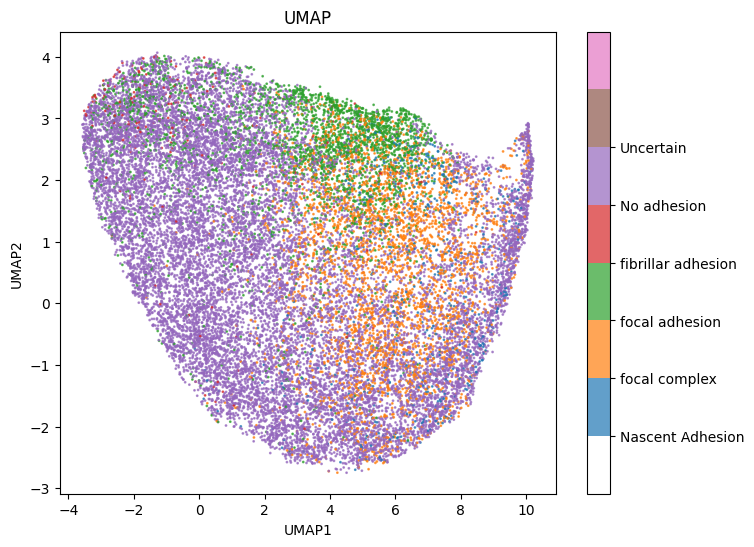

In [ ]:
import matplotlib.pyplot as plt
# fig = umap_2Dplot(latents_plus3_2d, 0,1,5-patch_label_df['group_labels']*0+1)
fig = plt.figure(figsize=(8, 6))
plt.scatter(umap_all_d0[y_all_pred_updated_mapping!=5], umap_all_d1[y_all_pred_updated_mapping!=5], c=y_all_pred_updated_mapping[y_all_pred_updated_mapping!=5], cmap='tab10', alpha=0.7, s=1, vmin=1, vmax=11)

cbar = plt.colorbar()
cbar.set_ticks(list(classification_label_to_color.values()))
cbar.set_ticklabels(list(classification_label_to_color.keys()))
cbar.ax.set_ylim(0, 8)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP") 